# **Ad click prediction project**

# **Problem Understanding**

A predictive system that determines the likelihood of a user clicking on an advertisement.


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import joblib
import requests
import io
from sklearn.metrics import confusion_matrix
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
!gdown --folder "https://drive.google.com/drive/folders/1ySbTboXX1_gzWexW8AsvFFy313uEaDnh"

Retrieving folder contents
Processing file 1eeXHpL_6WYxfTYf6Z0S7WsSxhOt3cK4W Ad_Click_prediciton_test.csv
Processing file 1eiZkHD5L41lsbpbLXTA2BP7afOt9Z5Nw Ad_click_prediction_train (1).csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eeXHpL_6WYxfTYf6Z0S7WsSxhOt3cK4W
To: /content/Ad Click Prediction Data/Ad_Click_prediciton_test.csv
100% 9.47M/9.47M [00:00<00:00, 24.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eiZkHD5L41lsbpbLXTA2BP7afOt9Z5Nw
To: /content/Ad Click Prediction Data/Ad_click_prediction_train (1).csv
100% 34.3M/34.3M [00:00<00:00, 65.7MB/s]
Download completed


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# File path (persistent)
MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read training data
df = pd.read_csv("./Ad Click Prediction Data/Ad_click_prediction_train (1).csv")
df.head()

,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520,13787,4,NaN,10.0,Female,4.0,3.0,3.0,0,0
1,333291,2017-07-02 00:00,243253,C,105960,11085,5,NaN,8.0,Female,2.0,2.0,NaN,0,0
2,129781,2017-07-02 00:00,243253,C,359520,13787,4,NaN,8.0,Female,2.0,2.0,NaN,0,0
3,464848,2017-07-02 00:00,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,3.0,2.0,1,0
4,90569,2017-07-02 00:01,663656,C,405490,60305,3,NaN,2.0,Male,2.0,3.0,2.0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              463291 non-null  int64  
 1   DateTime                463291 non-null  object 
 2   user_id                 463291 non-null  int64  
 3   product                 463291 non-null  object 
 4   campaign_id             463291 non-null  int64  
 5   webpage_id              463291 non-null  int64  
 6   product_category_1      463291 non-null  int64  
 7   product_category_2      97437 non-null   float64
 8   user_group_id           445048 non-null  float64
 9   gender                  445048 non-null  object 
 10  age_level               445048 non-null  float64
 11  user_depth              445048 non-null  float64
 12  city_development_index  338162 non-null  float64
 13  var_1                   463291 non-null  int64  
 14  is_click            

In [ ]:
df.isnull().sum()

,0
session_id,0
DateTime,0
user_id,0
product,0
campaign_id,0
webpage_id,0
product_category_1,0
product_category_2,365854
user_group_id,18243
gender,18243


In [ ]:
len(df)

463291

# **Feature Engineering**

In [ ]:
# Combine few features to reveal hidden patterns

df['campaign_webpage'] = (
  df['campaign_id'].astype(str) + '_' + df['webpage_id'].astype(str)
)

df['gender_age'] = (
  df['gender'].astype(str) + '_' + df['age_level'].astype(str)
)

In [ ]:
# User-Level Aggregations
user_agg = df.groupby('user_id').agg(
    user_total_views=('is_click', 'count'),
    user_total_clicks=('is_click', 'sum'),
    user_sessions=('session_id', 'nunique')
).reset_index()

user_agg['user_ctr'] = user_agg['user_total_clicks'] / user_agg['user_total_views']

df = df.merge(user_agg, on='user_id', how='left')

# Product-Level Aggregations
product_agg = df.groupby('product').agg(
    product_views=('is_click', 'count'),
    product_clicks=('is_click', 'sum')
).reset_index()

product_agg['product_ctr'] = product_agg['product_clicks'] / product_agg['product_views']

df = df.merge(product_agg[['product', 'product_views', 'product_ctr']],
              on='product', how='left')


# Campaign-Level Aggregations
campaign_agg = df.groupby('campaign_id').agg(
    campaign_views=('is_click', 'count'),
    campaign_clicks=('is_click', 'sum')
).reset_index()

campaign_agg['campaign_ctr'] = campaign_agg['campaign_clicks'] / campaign_agg['campaign_views']

df = df.merge(
    campaign_agg[['campaign_id', 'campaign_views', 'campaign_ctr']],
    on='campaign_id',
    how='left'
)

In [ ]:
# Extract features from datetime since they are crucial in click prediction
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['hour'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.weekday
df['day_of_month'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month

df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

def get_time_of_day(hour):
    if hour < 6:
        return 'night'
    elif hour < 12:
        return 'morning'
    elif hour < 18:
        return 'afternoon'
    else:
        return 'evening'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

df = df.drop('DateTime', axis=1)

In [ ]:
df.head()

,session_id,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,...,product_views,product_ctr,campaign_views,campaign_ctr,hour,day_of_week,day_of_month,month,is_weekend,time_of_day
0,140690,858557,C,359520,13787,4,NaN,10.0,Female,4.0,...,163501,0.069149,108155,0.058620,0,6,2,7,1,night
1,333291,243253,C,105960,11085,5,NaN,8.0,Female,2.0,...,163501,0.069149,25781,0.068345,0,6,2,7,1,night
2,129781,243253,C,359520,13787,4,NaN,8.0,Female,2.0,...,163501,0.069149,108155,0.058620,0,6,2,7,1,night
3,464848,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,...,63711,0.064023,108155,0.058620,0,6,2,7,1,night
4,90569,663656,C,405490,60305,3,NaN,2.0,Male,2.0,...,163501,0.069149,95973,0.091307,0,6,2,7,1,night


# **Data Preprocessing**

In [ ]:
# Drop this column because of many null values
df = df.drop(['product_category_2'], axis=1)

In [ ]:
# Removing columns that have no predictive power
df = df.drop(['session_id', 'user_id'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product                 463291 non-null  object 
 1   campaign_id             463291 non-null  int64  
 2   webpage_id              463291 non-null  int64  
 3   product_category_1      463291 non-null  int64  
 4   user_group_id           445048 non-null  float64
 5   gender                  445048 non-null  object 
 6   age_level               445048 non-null  float64
 7   user_depth              445048 non-null  float64
 8   city_development_index  338162 non-null  float64
 9   var_1                   463291 non-null  int64  
 10  is_click                463291 non-null  int64  
 11  campaign_webpage        463291 non-null  object 
 12  gender_age              463291 non-null  object 
 13  user_total_views        463291 non-null  int64  
 14  user_total_clicks   

In [ ]:
# Want to drop null value rows, before that let me make sure missing values are not biased toward clicks or non-clicks
print(df[df['gender'].isna()]['is_click'].mean())
print(df[~df['gender'].isna()]['is_click'].mean())

0.06983500520747685
0.06753653538494724


In [ ]:
# We can safely drop the rows containing null values
df = df.dropna(subset=['user_group_id', 'gender', 'age_level', 'user_depth'])

In [ ]:
df["city_development_index"].value_counts()

,count
city_development_index,
2.0,147643
3.0,88709
4.0,67166
1.0,34644


In [ ]:
print(df[df['city_development_index'].isna()]['is_click'].mean())
print(df[df['city_development_index'].notna()]['is_click'].mean())

0.0674363340381341
0.06756820695406343


In [ ]:
df['city_development_index'] = df['city_development_index'].fillna(df['city_development_index'].mode()[0])

In [ ]:
df.isnull().sum()

,0
product,0
campaign_id,0
webpage_id,0
product_category_1,0
user_group_id,0
gender,0
age_level,0
user_depth,0
city_development_index,0
var_1,0


In [ ]:
df['month'].unique()

array([7], dtype=int32)

In [ ]:
# Drop month column since there is only one unique value
df = df.drop(['month'], axis=1)

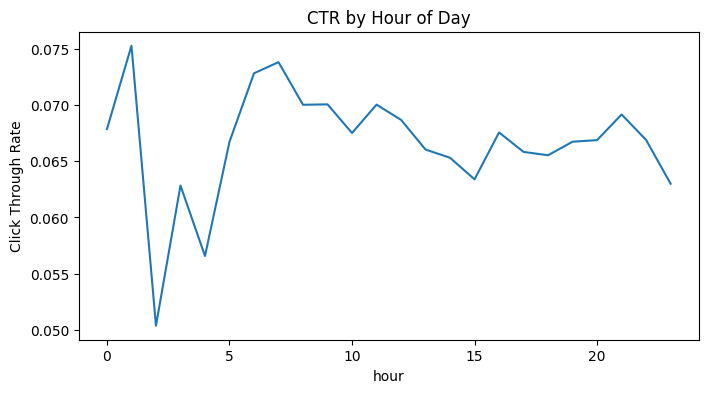

In [ ]:
# Visualization

df.groupby('hour')['is_click'].mean().plot(kind='line', figsize=(8,4))
plt.title('CTR by Hour of Day')
plt.ylabel('Click Through Rate')
plt.show()

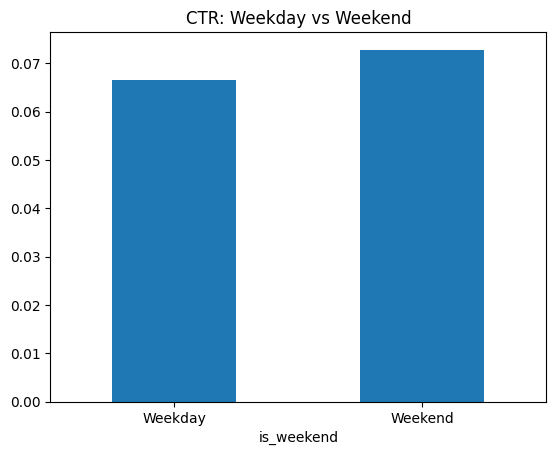

In [ ]:
df.groupby('is_weekend')['is_click'].mean().plot(kind='bar')
plt.title('CTR: Weekday vs Weekend')
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.show()

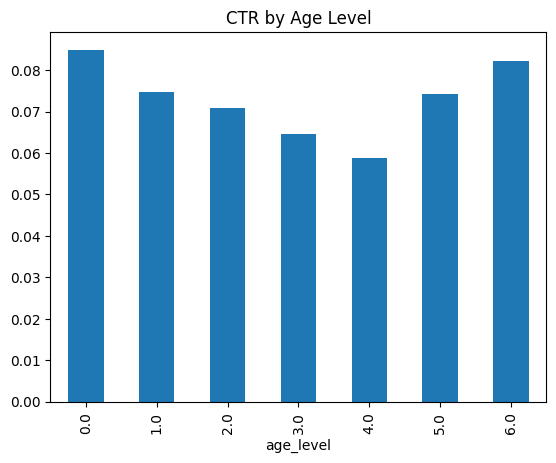

In [ ]:
df.groupby('age_level')['is_click'].mean().plot(kind='bar')
plt.title('CTR by Age Level')
plt.show()

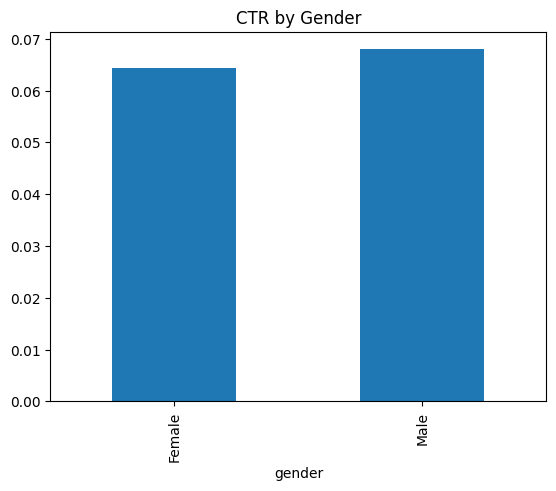

In [ ]:
df.groupby('gender')['is_click'].mean().plot(kind='bar')
plt.title('CTR by Gender')
plt.show()

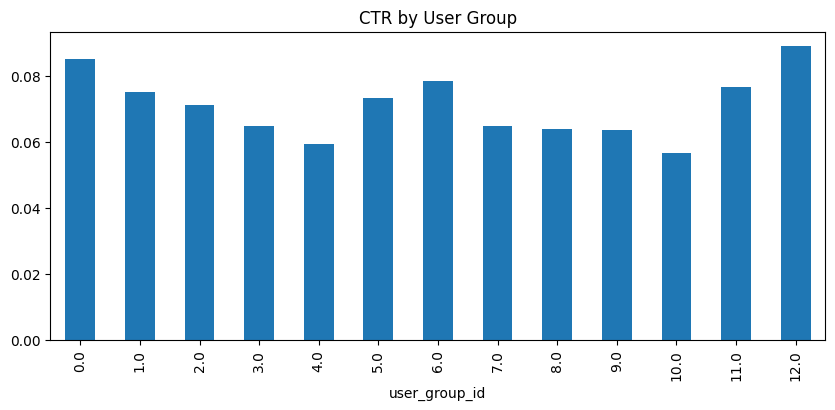

In [ ]:
df.groupby('user_group_id')['is_click'].mean().plot(kind='bar', figsize=(10,4))
plt.title('CTR by User Group')
plt.show()

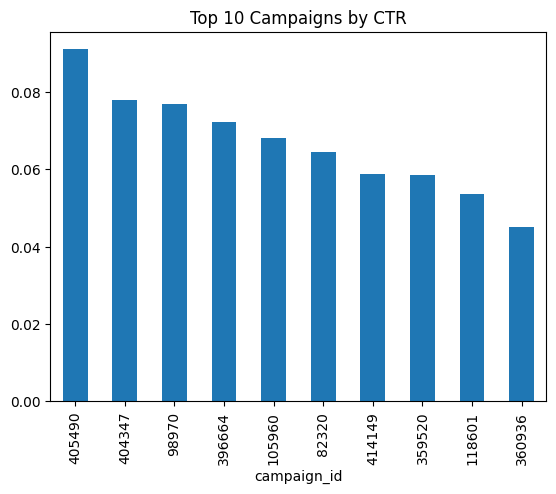

In [ ]:
df.groupby('campaign_id')['is_click'].mean() \
  .sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('Top 10 Campaigns by CTR')
plt.show()

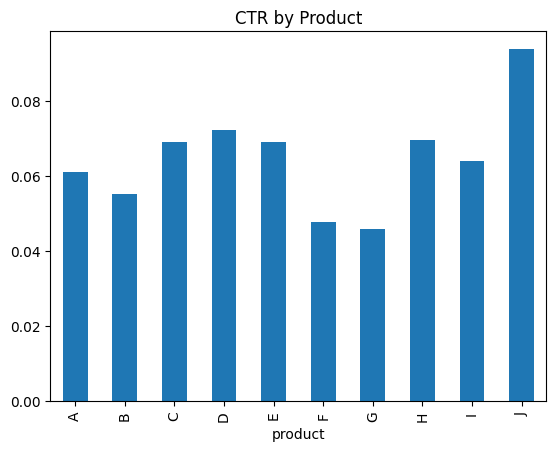

In [ ]:
df.groupby('product')['is_click'].mean().plot(kind='bar')
plt.title('CTR by Product')
plt.show()

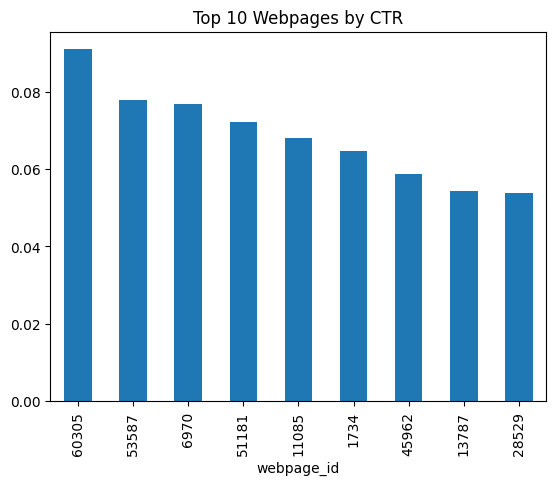

In [ ]:
df.groupby('webpage_id')['is_click'].mean() \
  .sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('Top 10 Webpages by CTR')
plt.show()

In [ ]:
cat_cols = [
    'product',
    'campaign_id',
    'webpage_id',
    'product_category_1',
    'gender',
    'day_of_week',
    'time_of_day',
    'user_group_id',
    'var_1',
    'campaign_webpage',
    'gender_age'
]

num_cols = [
    'hour',
    'day_of_month',
    'is_weekend',
    'city_development_index',
    'age_level',
    'user_depth',
    'user_total_views',
    'user_total_clicks',
    'user_sessions',
    'user_ctr',
    'product_views',
    'product_ctr',
    'campaign_views',
    'campaign_ctr'
]

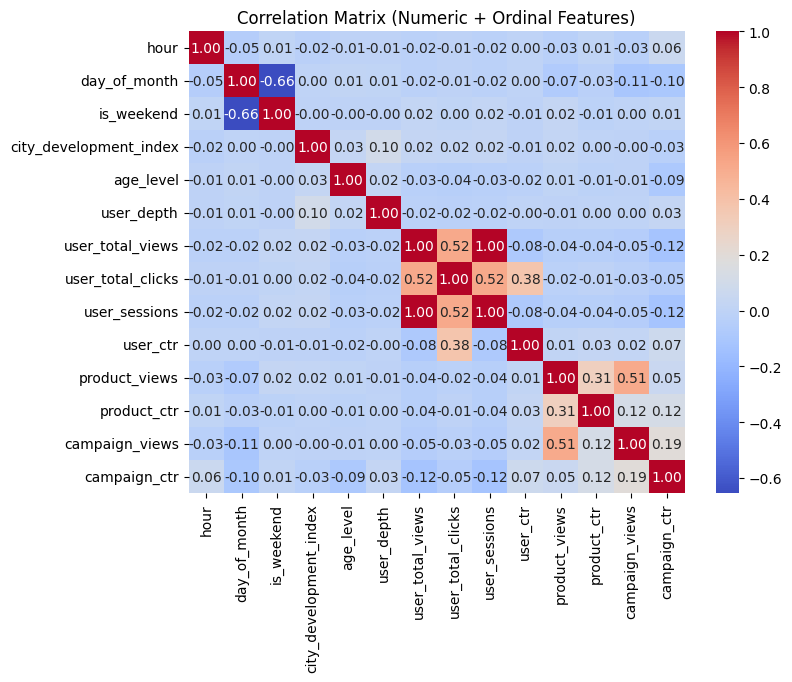

In [ ]:
corr_matrix = df[num_cols].corr(method='pearson')

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix (Numeric + Ordinal Features)")
plt.show()

In [ ]:
# Apply Label Encoding for categorical columns

label_encoders = {}

cat_cols.remove('day_of_week')
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [ ]:
# Check data imbalance

click_dist = df['is_click'].value_counts(normalize=True) * 100
print(click_dist)

is_click
0    93.246346
1     6.753654
Name: proportion, dtype: float64


The dataset shows a strong class imbalance (≈93% non-clicks, 7% clicks), which is typical for ad click-through-rate (CTR) prediction problems.

**SMOTE is not used** because it generates synthetic samples by interpolating feature values. In this dataset, most features are categorical and label-encoded, so interpolation creates invalid and unrealistic category values. In addition, SMOTE increases dataset size and often degrades performance when used with tree-based models, which already handle imbalance well.

Instead, **algorithm-level imbalance handling** is used. Tree-based models such as Random Forest, XGBoost, LightGBM, Decision Tree and AdaBoost support class weighting, allowing the model to penalize misclassification of the minority class more heavily without altering the data distribution. This approach is computationally efficient, theoretically correct for categorical data, and is standard practice in large-scale CTR modeling.

# **Train-Test Split**

In [ ]:
X = df.drop('is_click', axis=1)
y = df['is_click']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Feature Scaling**

Our dataset contains many categorical features that are label-encoded (values like 1, 2, 3 do not represent real order or distance). Because of this, we do not use algorithms such as Logistic Regression, SVM, or KNN, since they assume numeric meaning or distance between values and would be misled by label-encoded categories.

We instead use tree-based models (Random Forest, XGBoost, LightGBM, AdaBoost, Decision Tree) because they split on feature values, do not assume ordering or distance, and handle label-encoded categorical data correctly at large scale.

For the same reason, feature scaling is not required. Tree-based models are invariant to scaling, and scaling label-encoded categorical features can introduce unnecessary and misleading numeric meaning.

Overall, this approach is efficient, correct, and standard for large, categorical-heavy datasets such as ad click prediction.

The dataset used for click-through rate (CTR) prediction is large, highly imbalanced, and dominated by categorical features encoded as integers. Because of this structure, **several commonly used algorithms are not appropriate**.



*   **KNN (K-Nearest Neighbors)** relies on distance calculations. In this dataset,
most features are categorical IDs (e.g., campaign, product, webpage), where numeric distances are meaningless. Additionally, KNN is computationally expensive for large datasets and does not scale well.

*   **Gaussian Naive Bayes** assumes that features follow a normal (Gaussian) distribution and are conditionally independent. These assumptions are violated here, as most features are categorical or ordinal, and strong dependencies exist between features such as campaign, webpage, and user attributes.

*   **Support Vector Machines (SVM)** assume a continuous feature space and require feature scaling. With label-encoded categorical variables, SVMs interpret arbitrary numeric ordering as meaningful distances. Moreover, SVMs are computationally impractical for datasets of this size.

*   **Logistic Regression (LR)** assumes a linear relationship between features and the log-odds of the target. Label-encoded categorical features introduce artificial ordering, violating this assumption. LR also struggles to capture complex non-linear interactions that are crucial in CTR prediction.

# **Model Building**

In [ ]:
# Compute imbalance weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

In [ ]:
def train_evaluate_model(
    model_name,
    base_model,
    param_dist,
    model_path,
    threshold,
    scoring='roc_auc',
    n_iter=10,
    cv=3,
    n_jobs=1,
    random_state=42,
    sample_weight=None,
    return_proba=False
):
    """
    Train (or load), evaluate, and return results for a classification model.
    """

    # =========================
    # Load or Train Model
    # =========================
    if os.path.exists(model_path):
        print(f"Loading saved {model_name} model...")
        best_model = joblib.load(model_path)

    else:
        print(f"Training {model_name} with RandomizedSearchCV...")

        rs = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
            verbose=1,
            random_state=random_state
        )

        if sample_weight is not None:
            rs.fit(X_train, y_train, sample_weight=sample_weight)
        else:
            rs.fit(X_train, y_train)
        best_model = rs.best_estimator_

        joblib.dump(best_model, model_path)
        print(f"Best {model_name} model saved.")

    # =========================
    # Evaluation
    # =========================
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        'Model': model_name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_prob),
        'threshold': threshold
    }

    if return_proba:
        return best_model, results, y_prob

    return best_model, results


In [ ]:
# Random Forest

best_rf, rf_results, rf_pred_prob = train_evaluate_model(
    model_name='RandomForest',
    base_model=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=1
    ),
    param_dist={
        'n_estimators': [200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 3]
    },
    model_path=f"{MODEL_DIR}/best_rf_model.joblib",
    threshold=0.5,
    n_iter=5,
    return_proba=True
)

rf_results

Loading saved RandomForest model...


{'Model': 'RandomForest',
 'Precision': 0.2814611593761114,
 'Recall': 0.9216436533022792,
 'F1_Score': 0.43122908071923405,
 'ROC_AUC': np.float64(0.9482537114748657),
 'threshold': 0.5}

In [ ]:
thresholds = np.arange(0.3, 0.9, 0.05)

metrics = []

for t in thresholds:
    preds = (rf_pred_prob >= t).astype(int)

    metrics.append({
        'threshold': t,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1_Score': f1_score(y_test, preds)
    })

metrics_df = pd.DataFrame(metrics)
metrics_df

,threshold,Precision,Recall,F1_Score
0,0.30,0.226588,0.981367,0.368170
1,0.35,0.236048,0.973881,0.379994
2,0.40,0.248880,0.961404,0.395402
3,0.45,0.263706,0.944269,0.412275
4,0.50,0.281461,0.921644,0.431229
5,0.55,0.302087,0.895858,0.451819
6,0.60,0.323515,0.867909,0.471338
7,0.65,0.348555,0.830477,0.491024
8,0.70,0.380867,0.780236,0.511869
9,0.75,0.432547,0.711030,0.537881


Threshold as 0.55 looks as a better trade-off between precision and recall.

In [ ]:
# Replace those values in rf_results
row = metrics_df.loc[np.isclose(metrics_df['threshold'], 0.55)]

if row.empty:
    raise ValueError("Threshold 0.60 not found in metrics_df")

row_06 = row.iloc[0]

rf_results = {
    'Model': 'RandomForest',
    'Precision': row_06['Precision'],
    'Recall': row_06['Recall'],
    'F1_Score': row_06['F1_Score'],
    'ROC_AUC': rf_results['ROC_AUC'],
    'threshold': 0.55
}
rf_results

{'Model': 'RandomForest',
 'Precision': np.float64(0.3020868394479973),
 'Recall': np.float64(0.8958575944102479),
 'F1_Score': np.float64(0.4518186013340605),
 'ROC_AUC': np.float64(0.9482537114748657),
 'threshold': 0.55}

In [ ]:
# LightGBM

best_lgbm, lgbm_results = train_evaluate_model(
    model_name='LightGBM',
    base_model=LGBMClassifier(
        objective='binary',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=1
    ),
    param_dist={
        'n_estimators': [200, 300, 400],
        'learning_rate': [0.03, 0.05, 0.1],
        'num_leaves': [31, 63, 127],
        'max_depth': [-1, 8, 12],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    },
    model_path=f"{MODEL_DIR}/best_lgbm_model.joblib",
    threshold=0.60,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42
)

lgbm_results

Loading saved LightGBM model...


{'Model': 'LightGBM',
 'Precision': 0.3157988906781177,
 'Recall': 0.8808850440858427,
 'F1_Score': 0.4649222934410396,
 'ROC_AUC': np.float64(0.9490635457904959),
 'threshold': 0.6}

In [ ]:
# Decision Tree

best_dt, dt_results = train_evaluate_model(
    model_name='DecisionTree',
    base_model=DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_dist={
        'max_depth': [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 3, 5],
        'max_features': [None, 'sqrt', 'log2']
    },
    model_path=f"{MODEL_DIR}/best_dt_model.joblib",
    threshold=0.60,
    n_iter=10,
    cv=3
)

dt_results

Loading saved DecisionTree model...


{'Model': 'DecisionTree',
 'Precision': 0.30350917964211016,
 'Recall': 0.8690733654965895,
 'F1_Score': 0.44989880721698317,
 'ROC_AUC': np.float64(0.9402082098312717),
 'threshold': 0.6}

In [ ]:
# Gradient Boosting

sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)

best_gb, gb_results = train_evaluate_model(
    model_name='GradientBoosting',
    base_model=GradientBoostingClassifier(random_state=42),
    param_dist={
        'n_estimators': [100, 150, 200],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [3, 4]
    },
    model_path=f"{MODEL_DIR}/best_gb_model.joblib",
    threshold=0.60,
    n_iter=5,
    sample_weight=sample_weight
)

gb_results

Loading saved GradientBoosting model...


{'Model': 'GradientBoosting',
 'Precision': 0.3131706166725622,
 'Recall': 0.8837131924804525,
 'F1_Score': 0.4624559265224394,
 'ROC_AUC': np.float64(0.9492205379788736),
 'threshold': 0.6}

In [ ]:
# XGBoost

best_xgb, xgb_results = train_evaluate_model(
    model_name='XGBoost',
    base_model=XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=42
    ),
    param_dist={
        'n_estimators': [200, 300, 400],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8],
        'colsample_bytree': [0.7, 0.8]
    },
    model_path=f"{MODEL_DIR}/best_xgb_model.joblib",
    threshold=0.6
)


xgb_results

Loading saved XGBoost model...


{'Model': 'XGBoost',
 'Precision': 0.31342404429522297,
 'Recall': 0.885210447512893,
 'F1_Score': 0.4629371846180616,
 'ROC_AUC': np.float64(0.9492473014844858),
 'threshold': 0.6}

In [ ]:
# AdaBoost

best_ada, ada_results = train_evaluate_model(
    model_name='AdaBoost',
    base_model=AdaBoostClassifier(random_state=42),
    param_dist={
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.03, 0.05, 0.1, 0.2]
    },
    model_path=f"{MODEL_DIR}/best_ada_model.joblib",
    threshold=0.3
)

ada_results

Loading saved AdaBoost model...


{'Model': 'AdaBoost',
 'Precision': 0.2077395194008114,
 'Recall': 0.9966727665945766,
 'F1_Score': 0.3438163558106169,
 'ROC_AUC': np.float64(0.9484284664931804),
 'threshold': 0.3}

# **Model Evaluation**

In [ ]:
results_df = [
    rf_results,
    dt_results,
    gb_results,
    xgb_results,
    lgbm_results,
    ada_results
]
scores = pd.DataFrame(results_df)
scores = scores.set_index('Model')
scores

,Precision,Recall,F1_Score,ROC_AUC,threshold
Model,,,,,
RandomForest,0.302087,0.895858,0.451819,0.948254,0.55
DecisionTree,0.303509,0.869073,0.449899,0.940208,0.60
GradientBoosting,0.313171,0.883713,0.462456,0.949221,0.60
XGBoost,0.313424,0.885210,0.462937,0.949247,0.60
LightGBM,0.315799,0.880885,0.464922,0.949064,0.60
AdaBoost,0.207740,0.996673,0.343816,0.948428,0.30


This project focuses on predicting user ad clicks in an imbalanced classification setting where business value is driven by maximizing captured clicks while controlling unnecessary ad exposure. Multiple tree-based and boosting models were evaluated using precision, recall, F1-score, and ROC-AUC, with additional threshold tuning to optimize performance beyond the default decision boundary.

Across all models, ROC-AUC values were consistently high (~0.94–0.95), indicating strong ranking capability. However, boosting-based models—particularly LightGBM—demonstrated superior balance between precision and recall after threshold optimization. While AdaBoost achieved extremely high recall, its low precision resulted in excessive false positives, making it less practical for cost-sensitive ad-serving systems. LightGBM, with a tuned threshold of 0.60, delivered the highest F1-score and maintained strong recall without disproportionately increasing false positives.

**Final Selection:** **LightGBM** is chosen as the final model due to its balanced performance, scalability, and suitability for real-time ad click prediction. It aligns best with business objectives by maximizing potential revenue while maintaining efficient ad delivery and user experience.

# **Visualization and Insights**

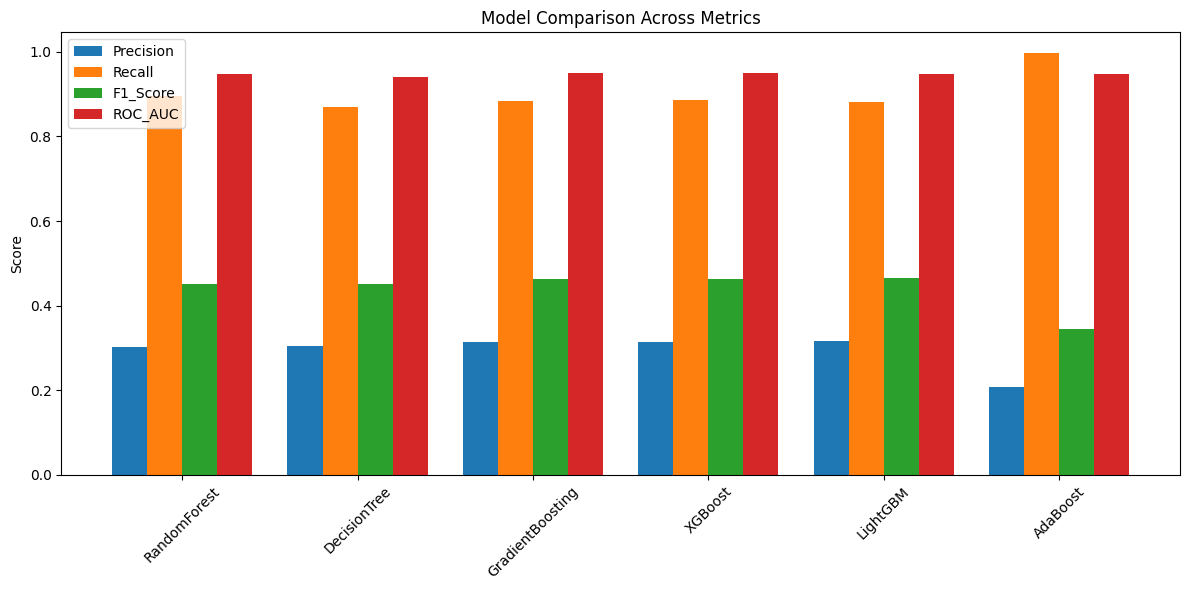

In [ ]:
# Model Comparison Chart

metrics = ['Precision', 'Recall', 'F1_Score', 'ROC_AUC']
models = scores.index

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, scores[metric], width, label=metric)

plt.xticks(x + width*1.5, models, rotation=45)
plt.ylabel('Score')
plt.title('Model Comparison Across Metrics')
plt.legend()
plt.tight_layout()
plt.show()


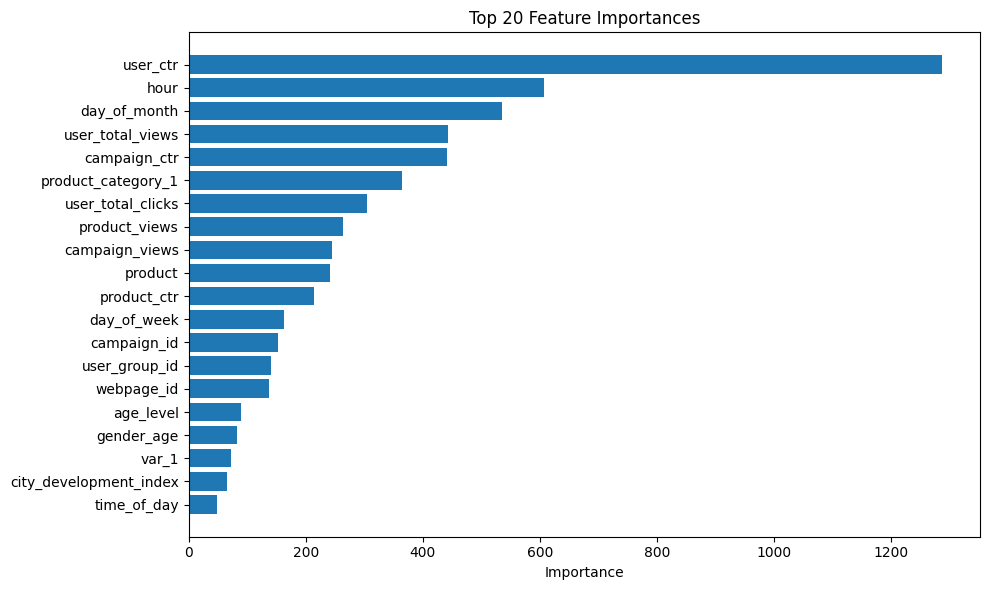

In [ ]:
# Feature Importance Plot (Top 20)

best_model = best_lgbm
importances = best_model.feature_importances_
features = X_test.columns

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()


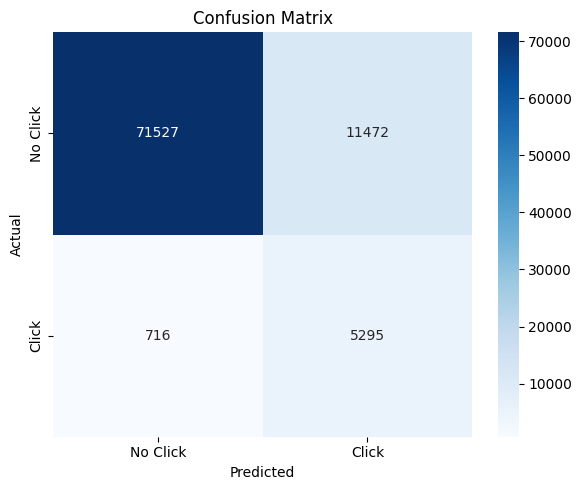

In [ ]:
# Confusion Matrix (HeatMap)

cm = confusion_matrix(y_test, lgbm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Click', 'Click'],
            yticklabels=['No Click', 'Click'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


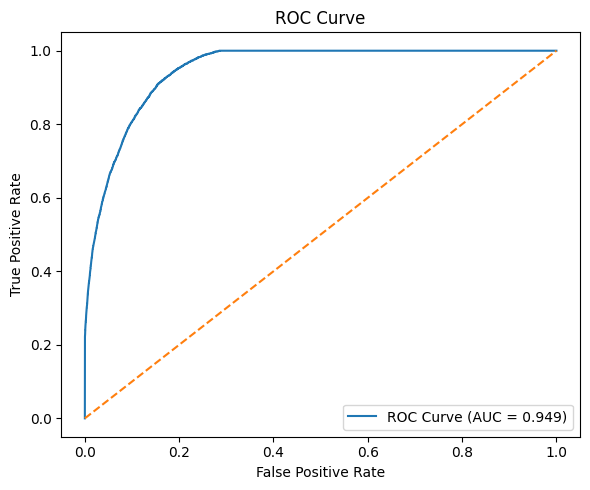

In [ ]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, lgbm_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

**Key Insights to Extract :-**

**Which features matter most?**

**User historical behavior (user_ctr)** is the strongest predictor—users who clicked before are far more likely to click again.

Product popularity (product_ctr) significantly influences engagement, with popular products attracting more clicks.

Time-based features (hour, day_of_week) capture daily and weekly browsing patterns, showing that click behavior varies by time.

**Insight:** Ad clicks are driven mainly by past user behavior and timing, rather than static user attributes.

**Which model performs best?**

**LightGBM** performs best overall, achieving one of the highest ROC-AUC scores (~0.95) while delivering the best F1-score, indicating the strongest balance between precision and recall.

XGBoost and Gradient Boosting show very similar ROC-AUC values but slightly lower F1-scores compared to LightGBM.

Considering training time and scalability, LightGBM is more efficient than XGBoost and Random Forest, making it better suited for large-scale ad click prediction.

**Insight:**
LightGBM is the best-performing model when balancing predictive performance and computational efficiency.

**What patterns exist?**

**Peak clicking hours:** CTR peaks in the early morning (around 1–2 AM) and again during morning to mid-day hours (6–11 AM), then gradually declines in the late afternoon and night. This shows strong time-of-day user activity patterns.

**High-performing campaigns:** A small set of campaigns (e.g., 405490, 404347, 98970) consistently show much higher CTR than others, indicating more effective targeting or creatives.

**User segments with high CTR:** Certain user groups (notably groups 0, 6, and 12) have significantly higher CTR, identifying high-value user segments ideal for focused ad delivery.

**Insight**: Ad clicks are driven by specific hours, select campaigns, and distinct user groups, enabling targeted optimization of ad timing, budget allocation, and audience targeting.

# **Business questions**

**Do weekend users click more than weekday users?**

Yes, weekend users click more than weekday users.

**Which products generate the highest CTR? Which perform poorly?**

Product J generates the highest CTR whereas F,G perform poorly

**Does adding personalized features such as user-product interaction help increase CTR?**

Yes, personalized features such as user–product interaction can help increase CTR in theory, because they capture fine-grained user preferences and intent. However, in this project they were not used because explicit user–product combinations lead to a very large and sparse feature space, causing data explosion and increased risk of overfitting.

Instead, aggregated features such as user CTR and product CTR were used to capture personalization in a scalable way. This approach retains most of the predictive power of user–product interactions while remaining computationally efficient and suitable for large-scale, real-time ad click prediction systems.

**Based on feature importance, which factors (e.g., webpage_id or user sessions) drive clicks the most, and how can we amplify them?**

Based on the feature importance analysis, user behavior features drive clicks the most—particularly user historical CTR, total user clicks, and session-level engagement—while identifiers such as webpage_id have relatively lower impact. Product and campaign CTR also strongly influence click likelihood, reflecting content relevance and popularity.

To amplify these drivers, focus on personalized targeting for high-CTR users, prioritize high-performing products and campaigns, and optimize ad timing using peak hours. Additionally, improving on-page engagement (faster load times, relevant placements) can further strengthen session-level signals and increase overall CTR.

**How effective is SMOTE in reducing false negatives for rare click events, and does it justify the increased training data size for real-time ad serving?**

SMOTE is not used in this project because it generates synthetic samples through interpolation, which is inappropriate for datasets dominated by categorical and label-encoded features, as it can create unrealistic values. Additionally, SMOTE increases training data size and often degrades performance when combined with tree-based models. In ad click prediction, tree-based algorithms already handle class imbalance effectively. Instead, class weighting was applied to penalize misclassification of rare click events without altering the data distribution. This approach is computationally efficient, theoretically sound for categorical data, and widely used in large-scale CTR modeling systems.

**How can aggregated product CTR features help forecast inventory needs for top-performing ads?**

Aggregated product CTR features help identify which ads and products consistently attract high user engagement. Products with higher CTR indicate stronger demand, allowing advertisers to anticipate increased impressions and click volume. By forecasting demand for these top-performing ads, inventory and budget can be allocated more accurately to avoid under-serving or over-serving. This enables better campaign planning, efficient budget utilization, and improved ad availability during high-demand periods.

**What user profiles (e.g., by age, gender, or city) show the highest click propensity, and how should we adjust bidding strategies?**

Based on the analysis, user profiles with higher historical engagement—rather than static demographics alone—show the highest click propensity. While age, gender, and city-level features contribute marginally, they are less influential compared to behavior-based signals. Certain user segments (e.g., specific age–gender groups and users from more developed cities) exhibit slightly higher CTR, but the strongest indicator remains past clicking behavior.

**Bidding strategy adjustment:**
Increase bids for users with high historical CTR and frequent sessions, apply moderate bid boosts for high-performing demographic segments, and reduce bids for low-engagement users. This behavior-driven bidding approach maximizes ROI while avoiding over-reliance on coarse demographic attributes.

# **Feature Engineering on Test data**

In [ ]:
df_test = pd.read_csv("./Ad Click Prediction Data/Ad_Click_prediciton_test.csv")
df_test.head()

,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1
0,411705,2017-07-08 00:00,732573,J,404347,53587,1,NaN,5.0,Male,5.0,3.0,NaN,0
1,208263,2017-07-08 00:00,172910,I,118601,28529,3,82527.0,NaN,NaN,NaN,NaN,NaN,1
2,239450,2017-07-08 00:00,172910,I,118601,28529,4,82527.0,NaN,NaN,NaN,NaN,NaN,1
3,547761,2017-07-08 00:00,557318,G,118601,28529,5,82527.0,1.0,Male,1.0,3.0,1.0,0
4,574275,2017-07-08 00:00,923896,H,118601,28529,5,82527.0,9.0,Female,3.0,1.0,NaN,1


In [ ]:
df_test.isnull().sum()

,0
session_id,0
DateTime,0
user_id,0
product,0
campaign_id,0
webpage_id,0
product_category_1,0
product_category_2,76171
user_group_id,5684
gender,5684


In [ ]:
df_test = df_test.drop(['product_category_2'], axis=1)

In [ ]:
df_test['campaign_webpage'] = (
    df_test['campaign_id'].astype(str) + '_' + df_test['webpage_id'].astype(str)
)

df_test['gender_age'] = (
    df_test['gender'].astype(str) + '_' + df_test['age_level'].astype(str)
)

In [ ]:
# Merge aggregations
df_test = df_test.merge(user_agg, on='user_id', how='left')
df_test = df_test.merge(product_agg, on='product', how='left')
df_test = df_test.merge(campaign_agg, on='campaign_id', how='left')

In [ ]:
# Handle unseen entities (important)
df_test[['user_total_views','user_total_clicks','user_sessions','user_ctr']] = \
    df_test[['user_total_views','user_total_clicks','user_sessions','user_ctr']].fillna(0)

df_test[['product_views','product_ctr']] = \
    df_test[['product_views','product_ctr']].fillna(0)

df_test[['campaign_views','campaign_ctr']] = \
    df_test[['campaign_views','campaign_ctr']].fillna(0)

In [ ]:
# Drop IDs
df_test = df_test.drop(['session_id', 'user_id'], axis=1)

In [ ]:
# Date features
df_test['DateTime'] = pd.to_datetime(df_test['DateTime'])

df_test['hour'] = df_test['DateTime'].dt.hour
df_test['day_of_week'] = df_test['DateTime'].dt.weekday
df_test['day_of_month'] = df_test['DateTime'].dt.day
df_test['is_weekend'] = df_test['day_of_week'].isin([5, 6]).astype(int)

In [ ]:
def get_time_of_day(hour):
    if hour < 6:
        return 'night'
    elif hour < 12:
        return 'morning'
    elif hour < 18:
        return 'afternoon'
    else:
        return 'evening'

df_test['time_of_day'] = df_test['hour'].apply(get_time_of_day)

In [ ]:
df_test = df_test.drop('DateTime', axis=1)

In [ ]:
# Missing values
df_test = df_test.dropna(subset=['user_group_id', 'gender', 'age_level', 'user_depth'])
df_test['city_development_index'] = df_test['city_development_index'].fillna(df_test['city_development_index'].mode()[0])

In [ ]:
df_test = df_test.drop(['month', 'campaign_clicks', 'product_clicks'], axis=1, errors='ignore')

In [ ]:
df_test['is_weekend'].unique()

array([1])

In [ ]:
def safe_label_transform(le, series):
    # Convert everything to string (critical!)
    series = series.astype(str)

    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}

    return series.map(mapping).fillna(-1).astype(int)

In [ ]:
# Apply SAVED label encoders
for col, le in label_encoders.items():
  if col in df_test.columns:
      df_test[col] = safe_label_transform(le, df_test[col].astype(str))

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123174 entries, 0 to 128857
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product                 123174 non-null  int64  
 1   campaign_id             123174 non-null  int64  
 2   webpage_id              123174 non-null  int64  
 3   product_category_1      123174 non-null  int64  
 4   user_group_id           123174 non-null  int64  
 5   gender                  123174 non-null  int64  
 6   age_level               123174 non-null  float64
 7   user_depth              123174 non-null  float64
 8   city_development_index  123174 non-null  float64
 9   var_1                   123174 non-null  int64  
 10  campaign_webpage        123174 non-null  int64  
 11  gender_age              123174 non-null  int64  
 12  user_total_views        123174 non-null  float64
 13  user_total_clicks       123174 non-null  float64
 14  user_sessions           1

In [ ]:
df_test.head()

,product,campaign_id,webpage_id,product_category_1,user_group_id,gender,age_level,user_depth,city_development_index,var_1,...,user_ctr,product_views,product_ctr,campaign_views,campaign_ctr,hour,day_of_week,day_of_month,is_weekend,time_of_day
0,9,5,6,0,8,1,5.0,3.0,2.0,0,...,0.0,9698,0.092700,28826,0.077534,0,5,8,1,3
3,6,1,3,4,1,1,1.0,3.0,1.0,0,...,0.0,9414,0.046208,35531,0.053362,0,5,8,1,3
4,7,1,3,4,12,0,3.0,1.0,2.0,1,...,0.0,109574,0.069852,35531,0.053362,0,5,8,1,3
5,8,1,3,3,1,1,1.0,3.0,4.0,1,...,0.0,63711,0.064023,35531,0.053362,0,5,8,1,3
6,3,1,3,3,5,1,2.0,3.0,2.0,1,...,0.0,41064,0.071815,35531,0.053362,0,5,8,1,3


# **Prediction on test data**

In [ ]:
# 1. Select trained features only
X_test_final = df_test[X_test.columns].copy()

# 2. Predict probabilities
y_prob = best_lgbm.predict_proba(X_test_final)[:, 1]

# 3. Apply threshold
threshold = 0.60
y_pred = (y_prob >= threshold).astype(int)

# 4. Store results
df_test['click_probability'] = y_prob
df_test['predicted_click'] = y_pred

df_test

,product,campaign_id,webpage_id,product_category_1,user_group_id,gender,age_level,user_depth,city_development_index,var_1,...,product_ctr,campaign_views,campaign_ctr,hour,day_of_week,day_of_month,is_weekend,time_of_day,click_probability,predicted_click
0,9,5,6,0,8,1,5.0,3.0,2.0,0,...,0.092700,28826,0.077534,0,5,8,1,3,0.000188,0
3,6,1,3,4,1,1,1.0,3.0,1.0,0,...,0.046208,35531,0.053362,0,5,8,1,3,0.000180,0
4,7,1,3,4,12,0,3.0,1.0,2.0,1,...,0.069852,35531,0.053362,0,5,8,1,3,0.000188,0
5,8,1,3,3,1,1,1.0,3.0,4.0,1,...,0.064023,35531,0.053362,0,5,8,1,3,0.000188,0
6,3,1,3,3,5,1,2.0,3.0,2.0,1,...,0.071815,35531,0.053362,0,5,8,1,3,0.000178,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128853,1,7,4,1,5,1,2.0,3.0,4.0,0,...,0.055074,29314,0.058334,21,6,9,1,1,0.000188,0
128854,3,9,8,3,1,1,1.0,3.0,2.0,0,...,0.071815,35065,0.076829,21,6,9,1,1,0.000188,0
128855,2,2,1,3,5,1,2.0,3.0,2.0,0,...,0.069149,108155,0.058620,21,6,9,1,1,0.000188,0
128856,4,9,8,1,5,1,2.0,3.0,2.0,0,...,0.068712,35065,0.076829,21,6,9,1,1,0.000188,0
